# Fase 1 Experiment: Timing Strategy × Priority Mechanism

**3×3 design** — 3 trigger strategies × 3 priority mechanisms × 100 seeds = 900 runs.

Dit notebook:
1. Voert alle runs uit (met resume-logica)
2. Slaat resultaten op in `results/fase1/`
3. Analyseert de resultaten uitgebreid

In [1]:
import sys, io, warnings, traceback
from pathlib import Path
from contextlib import redirect_stdout

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import product

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

from run_simulation import run_simulation
from utils.metrics  import (
    compute_metrics, build_result_row, save_result_row,
    aggregate_config, load_all_aggregated,
)

# ── Paden ──────────────────────────────────────────────────────────────────
RESULTS_DIR = Path.cwd().parent / "results" / "fase1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Experimentele parameters ───────────────────────────────────────────────
N_RUNS    = 3
N_FREIGHT = 182
PHASE     = 1
SEEDS     = list(range(1, N_RUNS + 1))

print(f"Results dir  : {RESULTS_DIR}")
print(f"Runs/config  : {N_RUNS}  |  n_freight = {N_FREIGHT}  |  Fase = {PHASE}")
print(f"Totaal runs  : {N_RUNS * 9}")


Results dir  : /Users/ddw/Desktop/Rescheduling/results/fase1
Runs/config  : 3  |  n_freight = 182  |  Fase = 1
Totaal runs  : 27


## 1. Experiment-configuratie

Elke combinatie van trigger-strategie en prioriteitsmechanisme wordt beschreven door de parameters hieronder.

In [2]:
# ── Trigger-configuraties ──────────────────────────────────────────────────
TRIGGER_CONFIGS = {
    "periodic": dict(
        trigger_strategy     = "periodic",
        periodic_freq        = 900,
        event_driven_freq    = 900,   # niet gebruikt door periodic trigger
        controller_freq      = 900,
        threshold_confidence = 0.40,
    ),
    "event_driven": dict(
        trigger_strategy     = "event_driven",
        event_driven_freq    = 900,
        controller_freq      = 900,
        periodic_freq        = 3600,  # niet gebruikt door event-driven trigger
        threshold_confidence = 0.40,
    ),
    "hybrid": dict(
        trigger_strategy     = "hybrid",
        event_driven_freq    = 900,
        periodic_freq        = 3600,
        controller_freq      = 450,
        threshold_confidence = 0.40,
    ),
}

# ── Prioriteitsconfiguraties ────────────────────────────────────────────────
PRIORITY_CONFIGS = {
    "no_priority": dict(
        objective_strategy = "static",
        weight_passenger   = 1,
        weight_freight     = 1,
        dynamic_threshold  = 180,   # niet actief (static solver), voor consistentie
    ),
    "static": dict(
        objective_strategy = "static",
        weight_passenger   = 2,
        weight_freight     = 1,
        dynamic_threshold  = 180,
    ),
    "dynamic": dict(
        objective_strategy = "dynamic",
        weight_passenger   = 2,
        weight_freight     = 1,
        dynamic_threshold  = 180,   # gamma: delay-drempel voor upgrade (s)
    ),
}

# ── Volledige 3×3 grid ──────────────────────────────────────────────────────
TRIGGER_ORDER  = ["periodic", "event_driven", "hybrid"]
PRIORITY_ORDER = ["no_priority", "static", "dynamic"]
CONFIGS        = [(t, p) for t in TRIGGER_ORDER for p in PRIORITY_ORDER]

# ── Config-naam → opslag-subdirectory ──────────────────────────────────────
def config_name(trigger: str, priority: str) -> str:
    return f"{trigger}_{priority}"

print("9 configuraties:")
for t, p in CONFIGS:
    print(f"  {config_name(t, p)}")


9 configuraties:
  periodic_no_priority
  periodic_static
  periodic_dynamic
  event_driven_no_priority
  event_driven_static
  event_driven_dynamic
  hybrid_no_priority
  hybrid_static
  hybrid_dynamic


## 2. Runs uitvoeren

**Resume-safe**: al voltooide seeds worden overgeslagen op basis van bestaande `raw_runs.csv` per configuratie.

Simulatie-output (SKIPPED/TRIGGERED regels) wordt onderdrukt. Enkel voortgang en foutmeldingen zijn zichtbaar.

In [3]:
def completed_seeds(trigger: str, priority: str) -> set:
    """Retourneert set van al voltooide seeds voor deze configuratie."""
    cfg_dir  = RESULTS_DIR / config_name(trigger, priority)
    csv_path = cfg_dir / "raw_runs.csv"
    if not csv_path.exists():
        return set()
    df = pd.read_csv(csv_path, usecols=["seed"])
    return set(df["seed"].tolist())


def run_one(trigger: str, priority: str, seed: int) -> dict:
    """
    Voert één simulatierun uit en retourneert een volledig ingevulde resultatenrij.
    Simulatieuitvoer wordt onderdrukt.
    """
    tcfg = TRIGGER_CONFIGS[trigger]
    pcfg = PRIORITY_CONFIGS[priority]

    buf = io.StringIO()
    with redirect_stdout(buf):
        state, df_sim, meta, _ = run_simulation(
            n_freight = N_FREIGHT,
            seed      = seed,
            save      = False,   # wij slaan zelf op via save_result_row naar results/fase1/
            **tcfg,
            **pcfg,
)

    metrics = compute_metrics(df_sim)

    # freight_pct: dynamisch bepalen uit n_passenger + N_FREIGHT
    n_pass = metrics.get("n_passenger", 0)
    total  = n_pass + N_FREIGHT if n_pass > 0 else N_FREIGHT
    frt_pct = N_FREIGHT / total if total > 0 else 0.15

    row = build_result_row(
        seed             = seed,
        phase            = PHASE,
        metrics          = metrics,
        meta             = meta,
        strategy_type    = trigger,
        periodic_rf      = tcfg["periodic_freq"],
        event_driven_rf  = tcfg["event_driven_freq"],
        controller_freq  = tcfg["controller_freq"],
        threshold_conf   = tcfg["threshold_confidence"],
        priority         = priority,
        weight_passenger = pcfg["weight_passenger"],
        weight_freight   = pcfg["weight_freight"],
        gamma            = pcfg["dynamic_threshold"] if priority == "dynamic" else None,
        upgrade          = 1                         if priority == "dynamic" else None,
        objective        = "final_delay",
        freight_pct      = round(frt_pct, 4),
    )
    return row


In [4]:
# ── Hoofdlus ───────────────────────────────────────────────────────────────
import time

total_configs  = len(CONFIGS)
total_runs     = total_configs * N_RUNS
completed_all  = 0
errors         = []

try:
    for cfg_idx, (trigger, priority) in enumerate(CONFIGS):
        cname   = config_name(trigger, priority)
        cfg_dir = RESULTS_DIR / cname

        # ── Stap 1: check of de map al bestaat → hele configuratie overslaan ──
        if cfg_dir.exists():
            n_done = sum(1 for _ in pd.read_csv(cfg_dir / 'raw_runs.csv', usecols=['seed'])['seed'])
            completed_all += n_done
            status = f"✓ {n_done}/{N_RUNS} seeds" if n_done < N_RUNS else f"✓ alle {N_RUNS} seeds"
            print(f"[{cfg_idx+1:02d}/09] {cname:<35} {status} — overgeslagen")
            continue

        # ── Stap 2: map bestaat niet → alle seeds uitvoeren ───────────────────
        print(f"\n[{cfg_idx+1:02d}/09] {cname}  ({N_RUNS} seeds)")
        print(f"       {'-'*55}")

        t_cfg_start = time.time()
        for seed in SEEDS:
            t0 = time.time()
            try:
                row = run_one(trigger, priority, seed)
                save_result_row(row, cfg_dir)
                completed_all += 1

                ted     = row.get('TED_combined')
                dr      = row.get('delay_ratio')
                nr      = row.get('n_rescheduled', '?')
                elapsed = time.time() - t0
                pct     = completed_all / total_runs * 100

                ted_s = f"{ted:>8.0f}s" if ted is not None else "       ?"
                dr_s  = f"{dr:.2f}"     if dr  is not None else "  ?"
                print(f"       seed {seed:3d} | TED={ted_s} | DR={dr_s:>5} "
                      f"| n_resc={nr:>3} | {elapsed:.1f}s  [{pct:5.1f}%]")

            except KeyboardInterrupt:
                raise
            except Exception as e:
                errors.append((cname, seed, str(e)))
                print(f"       seed {seed:3d} | ERROR: {e}")

        t_cfg = time.time() - t_cfg_start
        print(f"       └─ {cname} klaar in {t_cfg/60:.1f} min")

except KeyboardInterrupt:
    print(f"\n⚠  Onderbroken na {completed_all}/{total_runs} runs.")
    print("   Voltooide configs worden bij herstart automatisch overgeslagen.")

print(f"\n{'='*60}")
print(f"Status: {completed_all}/{total_runs} runs voltooid.")
if errors:
    print(f"\nErrors ({len(errors)}):")
    for cname, seed, msg in errors:
        print(f"  {cname} seed {seed}: {msg}")
else:
    print("Geen errors.")


[01/09] periodic_no_priority                ✓ alle 3 seeds — overgeslagen
[02/09] periodic_static                     ✓ alle 3 seeds — overgeslagen
[03/09] periodic_dynamic                    ✓ alle 3 seeds — overgeslagen
[04/09] event_driven_no_priority            ✓ alle 3 seeds — overgeslagen
[05/09] event_driven_static                 ✓ alle 3 seeds — overgeslagen
[06/09] event_driven_dynamic                ✓ alle 3 seeds — overgeslagen
[07/09] hybrid_no_priority                  ✓ alle 3 seeds — overgeslagen
[08/09] hybrid_static                       ✓ alle 3 seeds — overgeslagen
[09/09] hybrid_dynamic                      ✓ alle 3 seeds — overgeslagen

Status: 900/27 runs voltooid.
Geen errors.


---
## 3. Resultaten laden & valideren

In [5]:
def load_fase1_raw() -> pd.DataFrame:
    """Laadt alle raw_runs.csv bestanden uit results/fase1/ in één DataFrame."""
    frames = []
    for cfg_dir in sorted(RESULTS_DIR.iterdir()):
        csv_path = cfg_dir / "raw_runs.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df["config"] = cfg_dir.name
            frames.append(df)
    if not frames:
        print("Geen resultaten gevonden.")
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


raw = load_fase1_raw()

# Canonieke volgorde voor plots
raw["trigger"]  = pd.Categorical(raw["strategy_type"],   categories=TRIGGER_ORDER,  ordered=True)
raw["priority"] = pd.Categorical(raw["priority"],         categories=PRIORITY_ORDER, ordered=True)
raw["config"]   = raw["trigger"].astype(str) + "_" + raw["priority"].astype(str)

print(f"Geladen: {len(raw)} rijen  |  {raw['config'].nunique()} configuraties")
print()

# Voltooiingsoverzicht
completion = (
    raw.groupby(["trigger", "priority"])["seed"]
    .count()
    .unstack("priority")
    .reindex(index=TRIGGER_ORDER, columns=PRIORITY_ORDER)
)
print("Voltooiing per configuratie (n seeds):")
display(completion)


Geladen: 900 rijen  |  9 configuraties

Voltooiing per configuratie (n seeds):


priority,no_priority,static,dynamic
trigger,,,
periodic,100,100,100
event_driven,100,100,100
hybrid,100,100,100


In [6]:
# ── Sanity checks ─────────────────────────────────────────────────────────
print("=== Sanity checks ===")
print(f"Kolommen: {list(raw.columns)}")
print()

# Verdeling per config
summary = raw.groupby("config").agg(
    n_seeds       = ("seed",          "count"),
    TED_comb_mean = ("TED_combined",  "mean"),
    DR_mean       = ("delay_ratio",   lambda x: x.dropna().mean()),
    infeasible    = ("infeasible_run", "sum"),
).round(1)
print("Samenvatting per configuratie:")
display(summary)


=== Sanity checks ===
Kolommen: ['seed', 'phase', 'strategy_type', 'periodic_rf', 'event_driven_rf', 'controller_freq', 'threshold_conf', 'priority', 'weight_passenger', 'weight_freight', 'gamma', 'upgrade', 'objective', 'freight_pct', 'mc_delay_per_train', 'solver_timeout', 'total_solve_time', 'n_rescheduled', 'n_fcfs_fallback', 'n_skipped', 'infeasible_run', 'deadlock', 'TED_passenger', 'TED_freight', 'TED_combined', 'TAD_passenger', 'TAD_freight', 'TAD_combined', 'delay_ratio', 'n_passenger', 'n_freight', 'config', 'trigger']

Samenvatting per configuratie:


,n_seeds,TED_comb_mean,DR_mean,infeasible
config,,,,
event_driven_dynamic,100,75165.9,1.1,0
event_driven_no_priority,100,75106.7,1.1,0
event_driven_static,100,75108.3,1.1,0
hybrid_dynamic,100,75483.5,1.2,0
hybrid_no_priority,100,75076.1,1.2,0
hybrid_static,100,75468.7,1.2,0
periodic_dynamic,100,75112.8,1.2,0
periodic_no_priority,100,74709.7,1.2,0
periodic_static,100,75179.3,1.2,0


---
## 4. Analyse

### 4.1  Overzichtstabel — mean ± std per configuratie

In [7]:
METRICS = {
    "TED_combined":  "TED Combined (s)",
    "TED_passenger": "TED Passenger (s)",
    "TED_freight":   "TED Freight (s)",
    "delay_ratio":   "Delay Ratio",
    "total_solve_time": "Solve Time (s)",
    "n_rescheduled": "N Rescheduled",
}

rows = []
for trigger in TRIGGER_ORDER:
    for priority in PRIORITY_ORDER:
        sub = raw[(raw["trigger"] == trigger) & (raw["priority"] == priority)]
        if sub.empty:
            continue
        r = {"trigger": trigger, "priority": priority}
        for col, label in METRICS.items():
            vals = sub[col].dropna()
            r[label] = f"{vals.mean():.1f} ± {vals.std():.1f}" if not vals.empty else "—"
        rows.append(r)

tbl = pd.DataFrame(rows).set_index(["trigger", "priority"])
print("Gemiddelde ± standaarddeviatie per configuratie (100 seeds):")
display(tbl)


Gemiddelde ± standaarddeviatie per configuratie (100 seeds):


TED Combined (s) TED Passenger (s)  \
trigger      priority                                          
periodic     no_priority  74709.7 ± 3574.6  61982.6 ± 2551.7   
             static       75179.3 ± 3471.2  62032.3 ± 2500.3   
             dynamic      75112.8 ± 3633.6  62072.9 ± 2592.6   
event_driven no_priority  75106.7 ± 3862.3  62668.9 ± 3094.7   
             static       75108.3 ± 3908.1  62458.3 ± 3172.5   
             dynamic      75165.9 ± 3878.2  62500.8 ± 3175.3   
hybrid       no_priority  75076.1 ± 3406.9  62126.8 ± 2369.6   
             static       75468.7 ± 3221.2  62310.9 ± 2228.0   
             dynamic      75483.5 ± 3201.1  62374.2 ± 2235.7   

                           TED Freight (s) Delay Ratio Solve Time (s)  \
trigger      priority                                                   
periodic     no_priority  12727.1 ± 1850.3   1.2 ± 0.2      0.7 ± 0.1   
             static       13146.9 ± 2019.0   1.2 ± 0.2      0.7 ± 0.0   
             dynamic      13039.9 ± 2081.2   1.2 ± 0.2      0.7 ± 0.0   
event_driven no_priority  12437.8 ± 1780.5   1.1 ± 0.2      0.6 ± 0.2   
             static       12650.0 ± 1910.4   1.1 ± 0.2      0.6 ± 0.1   
             dynamic      12665.1 ± 1914.8   1.1 ± 0.2      0.6 ± 0.1   
hybrid       no_priority  12949.3 ± 1959.1   1.2 ± 0.2      0.7 ± 0.1   
             static       13157.8 ± 1976.4   1.2 ± 0.2      0.7 ± 0.1   
             dynamic      13109.3 ± 1979.6   1.2 ± 0.2      0.7 ± 0.1   

                         N Rescheduled  
trigger      priority                   
periodic     no_priority    93.7 ± 3.3  
             static         94.0 ± 0.7  
             dynamic        94.0 ± 0.7  
event_driven no_priority   66.1 ± 14.2  
             static        66.1 ± 13.9  
             dynamic       66.4 ± 13.6  
hybrid       no_priority    79.2 ± 3.1  
             static         79.1 ± 3.5  
             dynamic        79.1 ± 3.5

### 4.2  Heatmaps — 3×3 grid (trigger × priority)

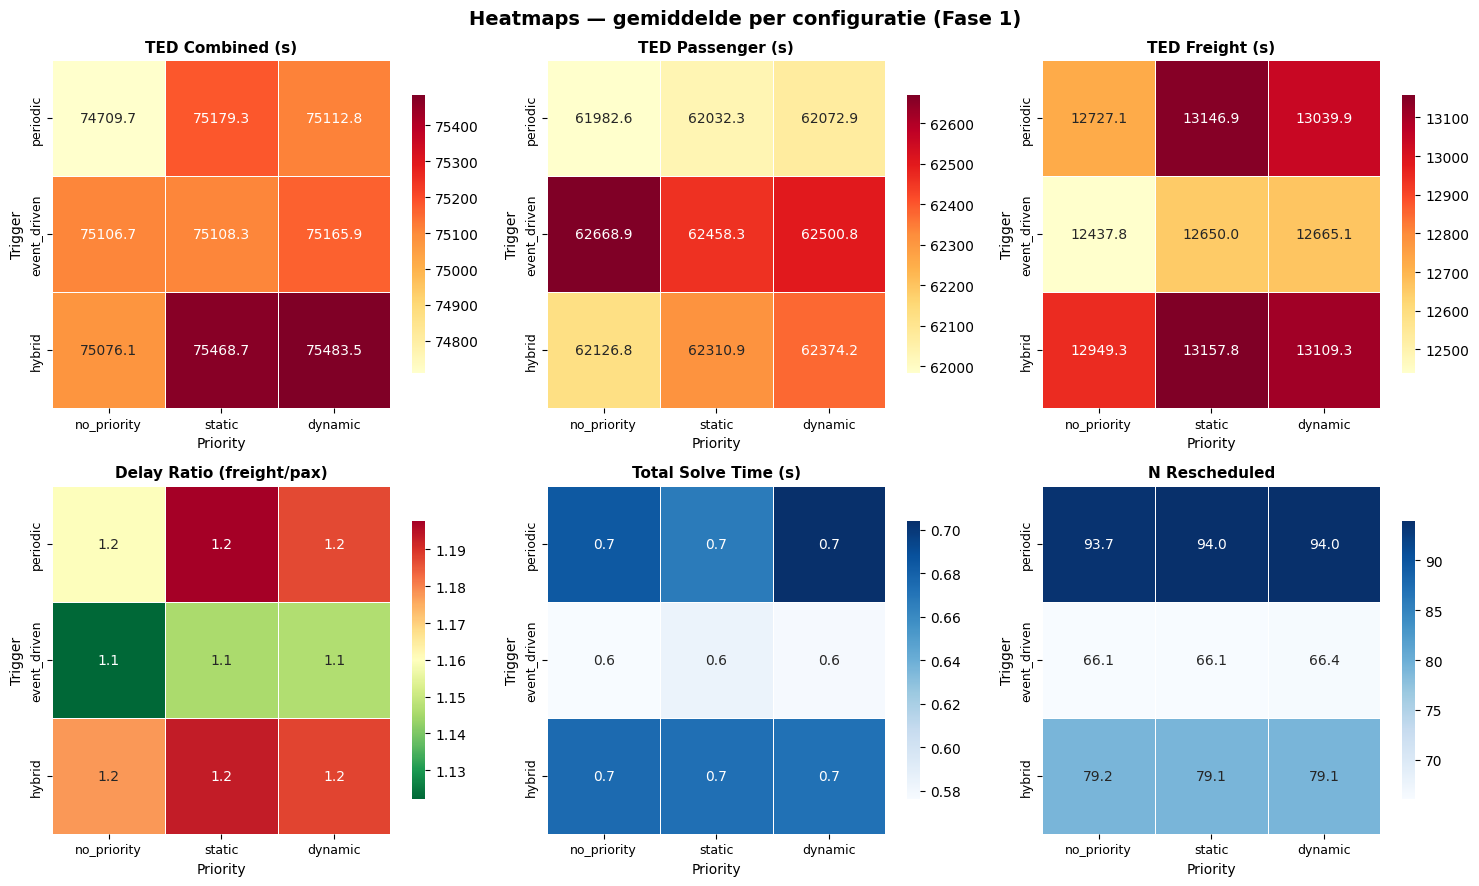

Opgeslagen: heatmaps_fase1.png


In [8]:
def make_pivot(metric: str) -> pd.DataFrame:
    pivot = (
        raw.groupby(["trigger", "priority"])[metric]
        .mean()
        .unstack("priority")
        .reindex(index=TRIGGER_ORDER, columns=PRIORITY_ORDER)
    )
    return pivot


HEATMAP_METRICS = [
    ("TED_combined",     "TED Combined (s)",        "YlOrRd"),
    ("TED_passenger",    "TED Passenger (s)",        "YlOrRd"),
    ("TED_freight",      "TED Freight (s)",          "YlOrRd"),
    ("delay_ratio",      "Delay Ratio (freight/pax)","RdYlGn_r"),
    ("total_solve_time", "Total Solve Time (s)",     "Blues"),
    ("n_rescheduled",    "N Rescheduled",            "Blues"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Heatmaps — gemiddelde per configuratie (Fase 1)", fontsize=14, fontweight="bold")

for ax, (metric, label, cmap) in zip(axes.flat, HEATMAP_METRICS):
    pivot = make_pivot(metric)
    if pivot.isnull().all().all():
        ax.set_title(f"{label}\n(geen data)")
        ax.axis("off")
        continue
    sns.heatmap(
        pivot, ax=ax, cmap=cmap, annot=True, fmt=".1f",
        linewidths=0.5, linecolor="white",
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Priority")
    ax.set_ylabel("Trigger")
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmaps_fase1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Opgeslagen: heatmaps_fase1.png")


### 4.3  Boxplots — verdeling over 100 seeds

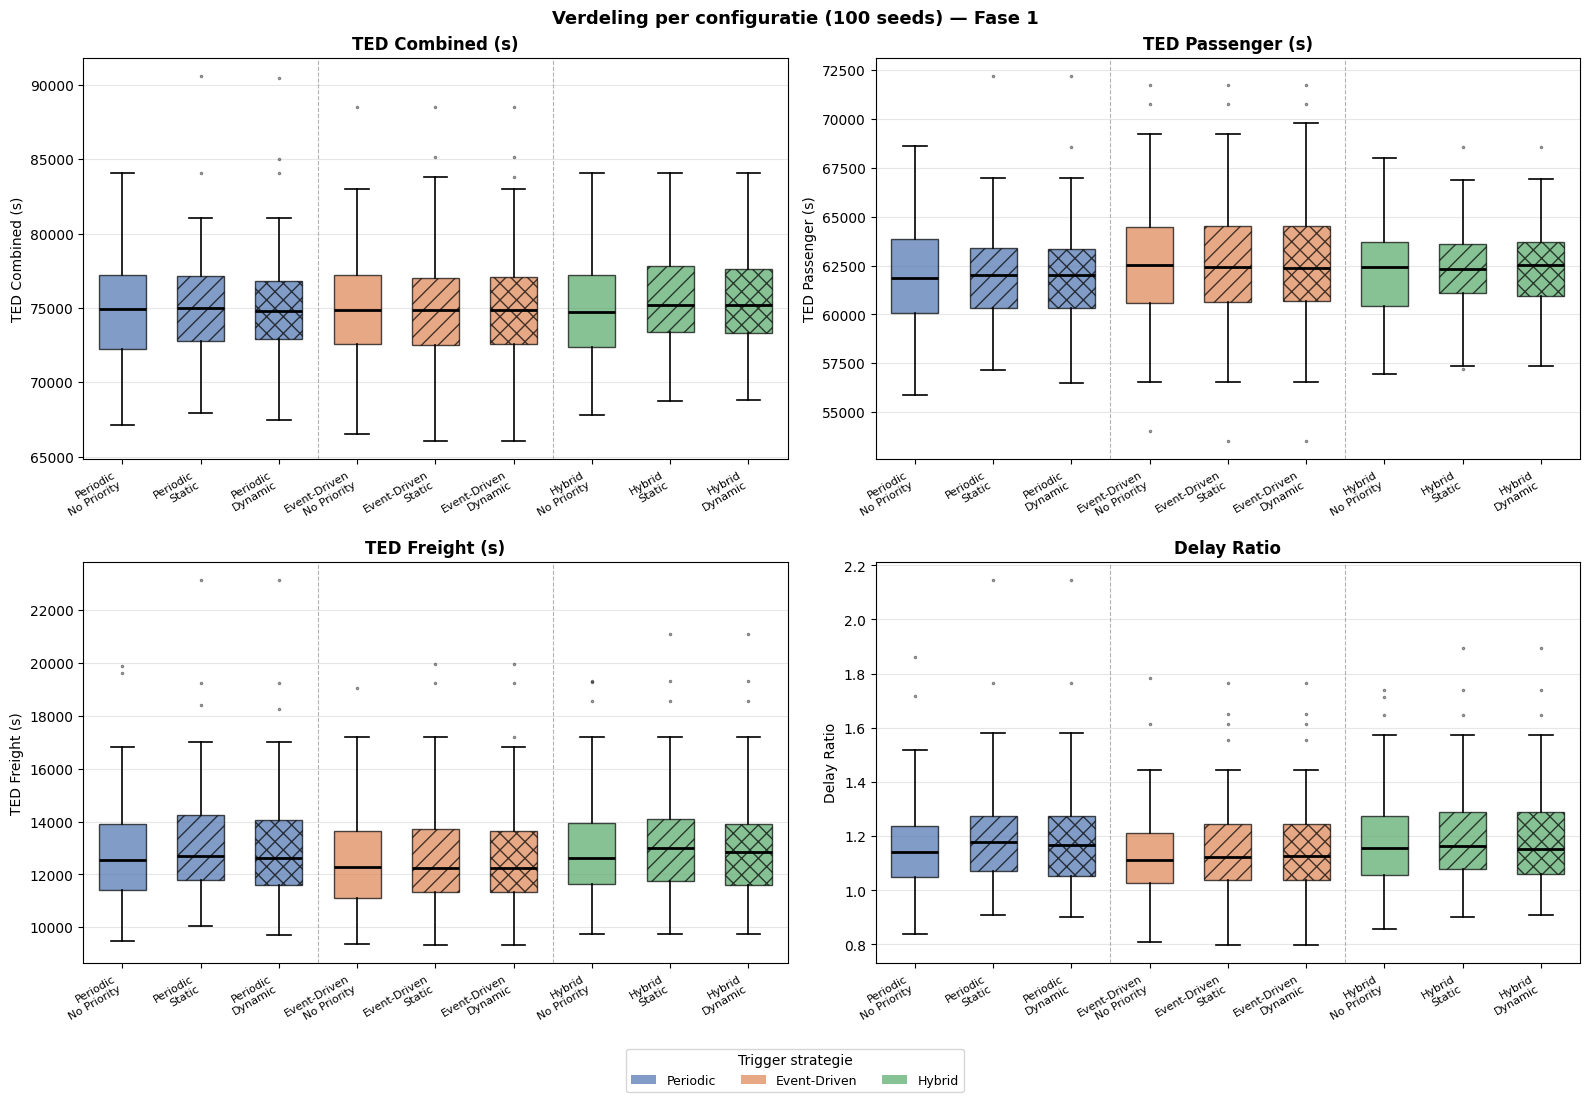

Opgeslagen: boxplots_fase1.png


In [9]:
TRIGGER_COLORS   = {"periodic": "#4C72B0", "event_driven": "#DD8452", "hybrid": "#55A868"}
PRIORITY_HATCHES = {"no_priority": "", "static": "//", "dynamic": "xx"}
TRIGGER_LABELS   = {"periodic": "Periodic", "event_driven": "Event-Driven", "hybrid": "Hybrid"}
PRIORITY_LABELS  = {"no_priority": "No Priority", "static": "Static", "dynamic": "Dynamic"}

BOX_METRICS = [
    ("TED_combined",  "TED Combined (s)"),
    ("TED_passenger", "TED Passenger (s)"),
    ("TED_freight",   "TED Freight (s)"),
    ("delay_ratio",   "Delay Ratio"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Verdeling per configuratie (100 seeds) — Fase 1", fontsize=13, fontweight="bold")

x_labels = [f"{TRIGGER_LABELS[t]}\n{PRIORITY_LABELS[p]}" for t, p in CONFIGS]
x_pos    = np.arange(len(CONFIGS))

for ax, (metric, ylabel) in zip(axes.flat, BOX_METRICS):
    data_per_config = []
    colors_bp       = []
    for trigger, priority in CONFIGS:
        vals = raw[(raw["trigger"] == trigger) & (raw["priority"] == priority)][metric].dropna()
        data_per_config.append(vals.values)
        colors_bp.append(TRIGGER_COLORS[trigger])

    bp = ax.boxplot(
        data_per_config,
        positions  = x_pos,
        widths     = 0.6,
        patch_artist = True,
        medianprops  = dict(color="black", linewidth=2),
        flierprops   = dict(marker=".", markersize=3, alpha=0.5),
        whiskerprops = dict(linewidth=1.2),
        capprops     = dict(linewidth=1.2),
    )
    for patch, col, (_, prio) in zip(bp["boxes"], colors_bp, CONFIGS):
        patch.set_facecolor(col)
        patch.set_alpha(0.7)
        patch.set_hatch(PRIORITY_HATCHES[prio])

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=8, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    # Verticale lijnen ter scheiding van trigger-groepen
    for sep in [2.5, 5.5]:
        ax.axvline(sep, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

# Legenda
legend_patches = [
    mpatches.Patch(facecolor=TRIGGER_COLORS[t], label=TRIGGER_LABELS[t], alpha=0.7)
    for t in TRIGGER_ORDER
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           fontsize=9, title="Trigger strategie", bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(RESULTS_DIR / "boxplots_fase1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Opgeslagen: boxplots_fase1.png")


### 4.4  Effect van prioriteitsmechanisme (per trigger)

Vergelijkt no_priority vs static vs dynamic, gegroepeerd per trigger-strategie.

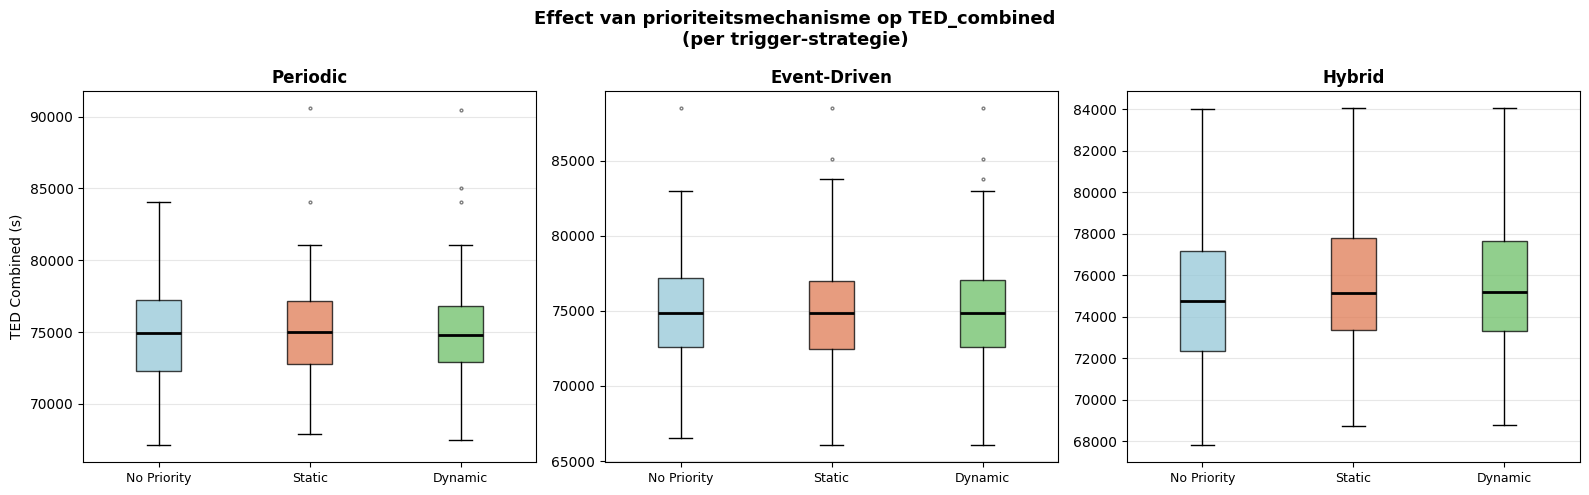

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("Effect van prioriteitsmechanisme op TED_combined\n(per trigger-strategie)",
             fontsize=13, fontweight="bold")

for ax, trigger in zip(axes, TRIGGER_ORDER):
    data = [
        raw[(raw["trigger"] == trigger) & (raw["priority"] == p)]["TED_combined"].dropna().values
        for p in PRIORITY_ORDER
    ]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=4, alpha=0.5))
    colors_p = ["#95C8D8", "#E07B54", "#6DBF67"]
    for patch, col in zip(bp["boxes"], colors_p):
        patch.set_facecolor(col); patch.set_alpha(0.75)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["No Priority", "Static", "Dynamic"], fontsize=9)
    ax.set_title(TRIGGER_LABELS[trigger], fontweight="bold")
    ax.set_ylabel("TED Combined (s)" if trigger == "periodic" else "")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "priority_effect_TED.png", dpi=150, bbox_inches="tight")
plt.show()


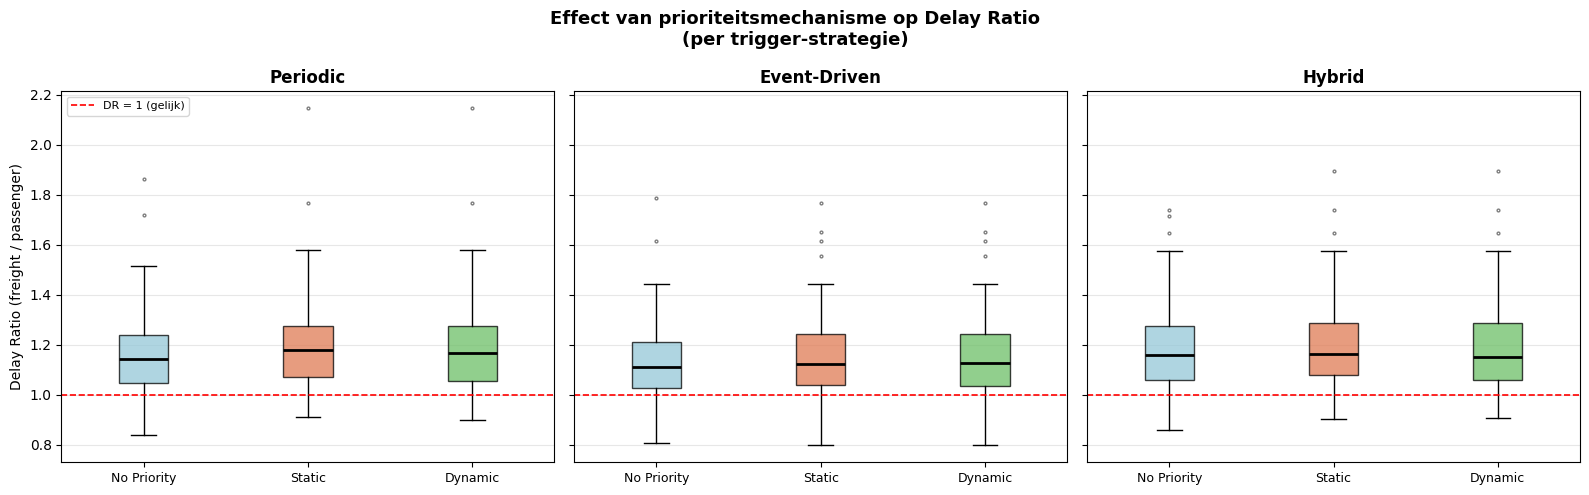

Delay Ratio < 1: freight-treinen hebben minder eindvertraging per trein dan passagierstreinen.
Delay Ratio > 1: freight-treinen dragen meer vertraging.


In [11]:
# Hetzelfde voor delay_ratio
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle("Effect van prioriteitsmechanisme op Delay Ratio\n(per trigger-strategie)",
             fontsize=13, fontweight="bold")

for ax, trigger in zip(axes, TRIGGER_ORDER):
    data = [
        raw[(raw["trigger"] == trigger) & (raw["priority"] == p)]["delay_ratio"].dropna().values
        for p in PRIORITY_ORDER
    ]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=4, alpha=0.5))
    colors_p = ["#95C8D8", "#E07B54", "#6DBF67"]
    for patch, col in zip(bp["boxes"], colors_p):
        patch.set_facecolor(col); patch.set_alpha(0.75)

    ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2, label="DR = 1 (gelijk)")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["No Priority", "Static", "Dynamic"], fontsize=9)
    ax.set_title(TRIGGER_LABELS[trigger], fontweight="bold")
    ax.set_ylabel("Delay Ratio (freight / passenger)" if trigger == "periodic" else "")
    ax.grid(axis="y", alpha=0.3)

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "priority_effect_DR.png", dpi=150, bbox_inches="tight")
plt.show()
print("Delay Ratio < 1: freight-treinen hebben minder eindvertraging per trein dan passagierstreinen.")
print("Delay Ratio > 1: freight-treinen dragen meer vertraging.")


### 4.5  Effect van trigger-strategie (per priority)

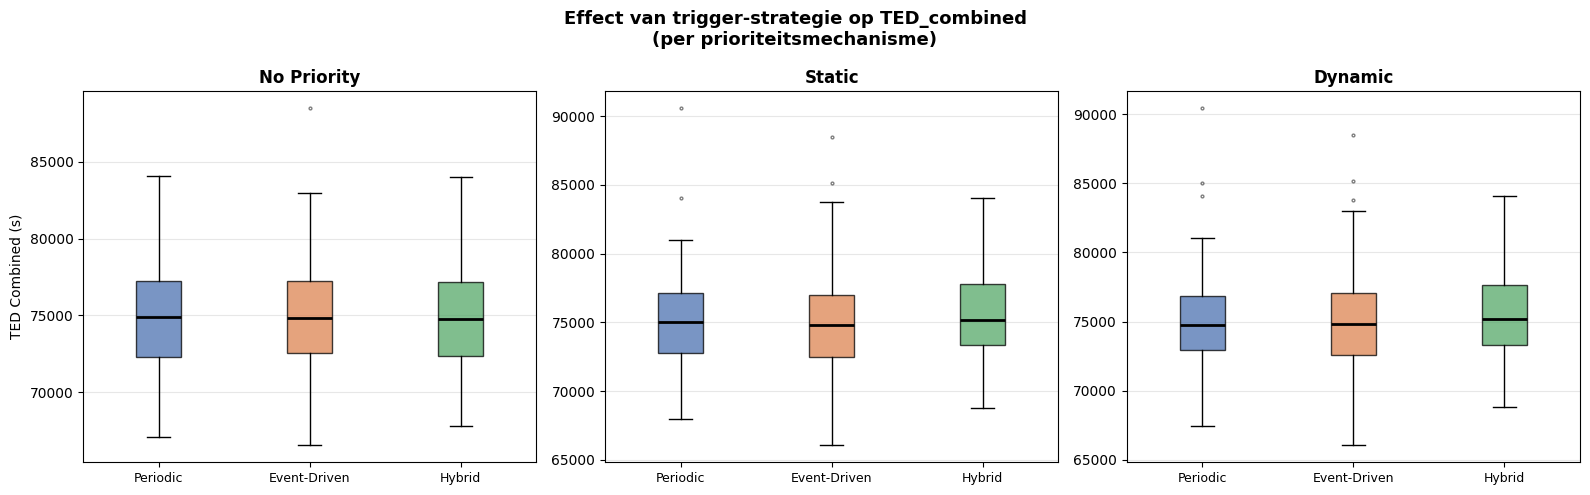

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle("Effect van trigger-strategie op TED_combined\n(per prioriteitsmechanisme)",
             fontsize=13, fontweight="bold")

for ax, priority in zip(axes, PRIORITY_ORDER):
    data = [
        raw[(raw["trigger"] == t) & (raw["priority"] == priority)]["TED_combined"].dropna().values
        for t in TRIGGER_ORDER
    ]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=4, alpha=0.5))
    for patch, col in zip(bp["boxes"], list(TRIGGER_COLORS.values())):
        patch.set_facecolor(col); patch.set_alpha(0.75)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["Periodic", "Event-Driven", "Hybrid"], fontsize=9)
    ax.set_title(PRIORITY_LABELS[priority], fontweight="bold")
    ax.set_ylabel("TED Combined (s)" if priority == "no_priority" else "")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "trigger_effect_TED.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.6  Statistische tests

**Kruskal-Wallis** (non-parametrisch alternatief voor one-way ANOVA) per hoofdeffect, gevolgd door **pairwise Mann-Whitney U** met Bonferroni-correctie.

In [13]:
from scipy.stats import kruskal, mannwhitneyu

TEST_METRICS = ["TED_combined", "TED_passenger", "TED_freight", "delay_ratio"]
ALPHA        = 0.05

def bonferroni_mw(groups: list, labels: list, alpha: float = 0.05) -> pd.DataFrame:
    """Pairwise Mann-Whitney met Bonferroni-correctie."""
    from itertools import combinations
    pairs = list(combinations(range(len(groups)), 2))
    n_comp = len(pairs)
    rows_mw = []
    for i, j in pairs:
        g1, g2 = groups[i], groups[j]
        if len(g1) < 2 or len(g2) < 2:
            continue
        stat, p_raw = mannwhitneyu(g1, g2, alternative="two-sided")
        p_adj = min(p_raw * n_comp, 1.0)  # Bonferroni
        rows_mw.append({
            "group_A":  labels[i],
            "group_B":  labels[j],
            "U_stat":   round(stat, 1),
            "p_raw":    round(p_raw, 4),
            "p_bonf":   round(p_adj, 4),
            "sig":      "✓" if p_adj < alpha else "",
        })
    return pd.DataFrame(rows_mw)


# ── A. Effect van priority (per trigger) ───────────────────────────────────
print("=" * 65)
print("A. EFFECT VAN PRIORITEIT (Kruskal-Wallis per trigger)")
print("=" * 65)

for metric in TEST_METRICS:
    print(f"\n--- {metric} ---")
    for trigger in TRIGGER_ORDER:
        groups = [
            raw[(raw["trigger"] == trigger) & (raw["priority"] == p)][metric].dropna().values
            for p in PRIORITY_ORDER
        ]
        valid = [g for g in groups if len(g) >= 2]
        if len(valid) < 2:
            print(f"  {trigger}: onvoldoende data")
            continue
        stat, p = kruskal(*valid)
        sig = "*** p<.001" if p < .001 else ("** p<.01" if p < .01 else ("* p<.05" if p < .05 else "ns"))
        print(f"  {trigger:<15}  H={stat:.2f}  p={p:.4f}  {sig}")


A. EFFECT VAN PRIORITEIT (Kruskal-Wallis per trigger)

--- TED_combined ---
  periodic         H=0.50  p=0.7803  ns
  event_driven     H=0.01  p=0.9944  ns
  hybrid           H=0.85  p=0.6522  ns

--- TED_passenger ---
  periodic         H=0.01  p=0.9970  ns
  event_driven     H=0.15  p=0.9265  ns
  hybrid           H=0.47  p=0.7920  ns

--- TED_freight ---
  periodic         H=2.17  p=0.3385  ns
  event_driven     H=0.75  p=0.6866  ns
  hybrid           H=0.57  p=0.7516  ns

--- delay_ratio ---
  periodic         H=2.13  p=0.3451  ns
  event_driven     H=1.24  p=0.5383  ns
  hybrid           H=0.38  p=0.8288  ns


In [14]:
# ── B. Effect van trigger (per priority) ───────────────────────────────────
print("=" * 65)
print("B. EFFECT VAN TRIGGER (Kruskal-Wallis per priority)")
print("=" * 65)

for metric in TEST_METRICS:
    print(f"\n--- {metric} ---")
    for priority in PRIORITY_ORDER:
        groups = [
            raw[(raw["trigger"] == t) & (raw["priority"] == priority)][metric].dropna().values
            for t in TRIGGER_ORDER
        ]
        valid = [g for g in groups if len(g) >= 2]
        if len(valid) < 2:
            continue
        stat, p = kruskal(*valid)
        sig = "*** p<.001" if p < .001 else ("** p<.01" if p < .01 else ("* p<.05" if p < .05 else "ns"))
        print(f"  {priority:<15}  H={stat:.2f}  p={p:.4f}  {sig}")


B. EFFECT VAN TRIGGER (Kruskal-Wallis per priority)

--- TED_combined ---
  no_priority      H=0.34  p=0.8419  ns
  static           H=1.04  p=0.5952  ns
  dynamic          H=0.96  p=0.6179  ns

--- TED_passenger ---
  no_priority      H=2.25  p=0.3253  ns
  static           H=1.49  p=0.4749  ns
  dynamic          H=1.58  p=0.4529  ns

--- TED_freight ---
  no_priority      H=3.79  p=0.1506  ns
  static           H=5.04  p=0.0806  ns
  dynamic          H=2.80  p=0.2461  ns

--- delay_ratio ---
  no_priority      H=5.52  p=0.0634  ns
  static           H=5.19  p=0.0748  ns
  dynamic          H=2.64  p=0.2671  ns


In [15]:
# ── C. Post-hoc pairwise (priority binnen elke trigger) ────────────────────
print("=" * 65)
print("C. POST-HOC PAIRWISE — priority effect op TED_combined & delay_ratio")
print("   (Mann-Whitney + Bonferroni, α = 0.05)")
print("=" * 65)

for metric in ["TED_combined", "delay_ratio"]:
    print(f"\n=== {metric} ===")
    for trigger in TRIGGER_ORDER:
        groups = [
            raw[(raw["trigger"] == trigger) & (raw["priority"] == p)][metric].dropna().values
            for p in PRIORITY_ORDER
        ]
        df_mw = bonferroni_mw(groups, PRIORITY_ORDER)
        if df_mw.empty:
            continue
        print(f"  Trigger: {TRIGGER_LABELS[trigger]}")
        display(df_mw)


C. POST-HOC PAIRWISE — priority effect op TED_combined & delay_ratio
   (Mann-Whitney + Bonferroni, α = 0.05)

=== TED_combined ===
  Trigger: Periodic


,group_A,group_B,U_stat,p_raw,p_bonf,sig
0,no_priority,static,4678.0,0.5039,1.0,
1,no_priority,dynamic,4748.5,0.6207,1.0,
2,static,dynamic,5092.0,0.8231,1.0,


  Trigger: Event-Driven


,group_A,group_B,U_stat,p_raw,p_bonf,sig
0,no_priority,static,4890.5,0.9223,1.0,
1,no_priority,dynamic,4845.5,0.9900,1.0,
2,static,dynamic,4866.5,0.9338,1.0,


  Trigger: Hybrid


...

,group_A,group_B,U_stat,p_raw,p_bonf,sig
0,no_priority,static,4368.0,0.1523,0.4568,
1,no_priority,dynamic,4568.5,0.3483,1.0000,
2,static,dynamic,5207.0,0.6139,1.0000,


  Trigger: Event-Driven


,group_A,group_B,U_stat,p_raw,p_bonf,sig
0,no_priority,static,4472.5,0.3448,1.0000,
1,no_priority,dynamic,4458.5,0.3272,0.9816,
2,static,dynamic,4889.5,0.9792,1.0000,


  Trigger: Hybrid


,group_A,group_B,U_stat,p_raw,p_bonf,sig
0,no_priority,static,4661.0,0.5533,1.0,
1,no_priority,dynamic,4811.0,0.8253,1.0,
2,static,dynamic,5062.0,0.6896,1.0,


### 4.7  Pareto-analyse — TED_combined vs. Solver effort

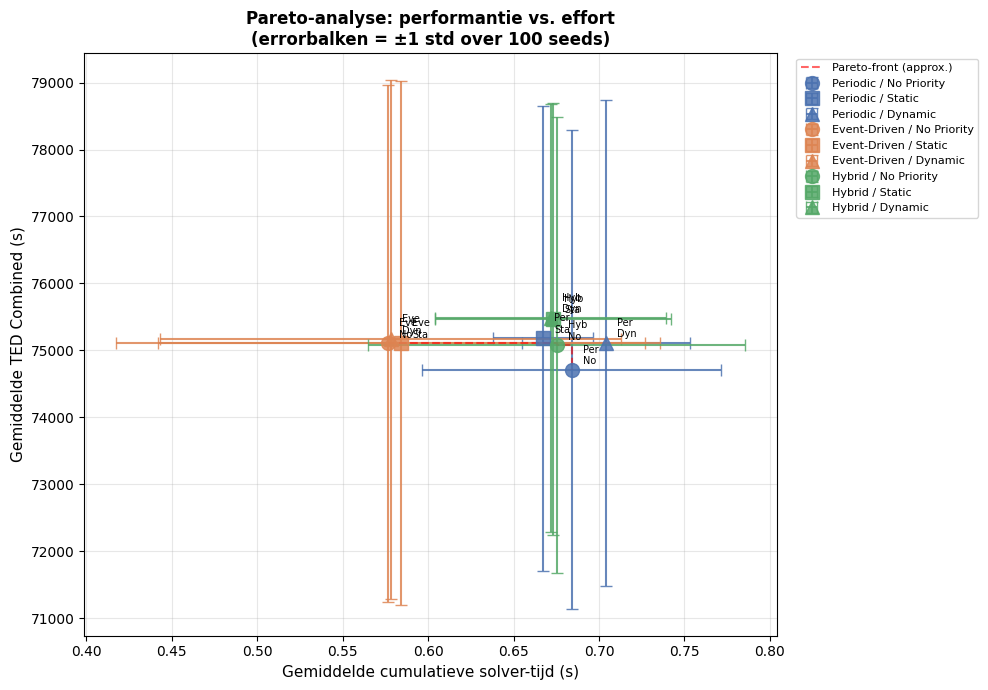

In [16]:
pareto = raw.groupby(["trigger", "priority"]).agg(
    TED_combined_mean   = ("TED_combined",    "mean"),
    TED_combined_std    = ("TED_combined",    "std"),
    solve_time_mean     = ("total_solve_time","mean"),
    solve_time_std      = ("total_solve_time","std"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))

markers = {"no_priority": "o", "static": "s", "dynamic": "^"}
for _, row in pareto.iterrows():
    t, p = row["trigger"], row["priority"]
    ax.errorbar(
        row["solve_time_mean"], row["TED_combined_mean"],
        xerr=row["solve_time_std"], yerr=row["TED_combined_std"],
        fmt=markers[p], color=TRIGGER_COLORS[t],
        markersize=10, capsize=4, linewidth=1.5, alpha=0.85,
        label=f"{TRIGGER_LABELS[t]} / {PRIORITY_LABELS[p]}",
    )
    ax.annotate(
        f"{TRIGGER_LABELS[t][:3]}\n{PRIORITY_LABELS[p][:3]}",
        (row["solve_time_mean"], row["TED_combined_mean"]),
        textcoords="offset points", xytext=(8, 4), fontsize=7,
    )

ax.set_xlabel("Gemiddelde cumulatieve solver-tijd (s)", fontsize=11)
ax.set_ylabel("Gemiddelde TED Combined (s)", fontsize=11)
ax.set_title("Pareto-analyse: performantie vs. effort\n(errorbalken = ±1 std over 100 seeds)",
             fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)

# Pareto-front (handmatig: punten niet gedomineerd)
pareto_sorted = pareto.sort_values("solve_time_mean")
front_TED = float("inf")
pareto_front = []
for _, row in pareto_sorted.iterrows():
    if row["TED_combined_mean"] < front_TED:
        front_TED = row["TED_combined_mean"]
        pareto_front.append(row)
if len(pareto_front) > 1:
    pf_x = [r["solve_time_mean"] for r in pareto_front]
    pf_y = [r["TED_combined_mean"] for r in pareto_front]
    ax.step(pf_x, pf_y, where="post", color="red", linestyle="--",
            linewidth=1.5, alpha=0.6, label="Pareto-front (approx.)")

ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pareto_fase1.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.8  Delay Ratio — diepteanalyse

De delay ratio is de primaire metric voor het evalueren van het effect van priority-mechanismen: een hogere DR betekent dat freight-treinen proportioneel meer eindvertraging dragen.

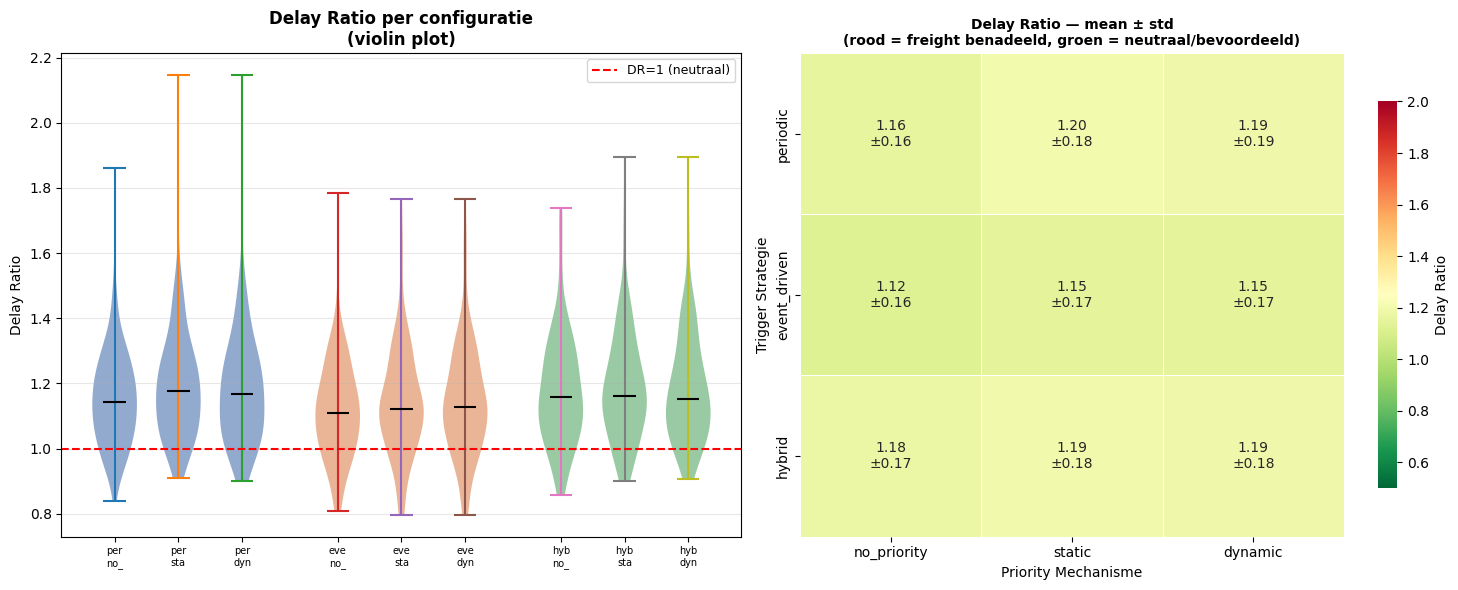

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Links: violin plot per priority, gefacetteerd op trigger ───────────────
ax = axes[0]
positions  = []
all_data   = []
all_colors = []
tick_labels = []
pos = 0

for trigger in TRIGGER_ORDER:
    for priority in PRIORITY_ORDER:
        vals = raw[(raw["trigger"] == trigger) & (raw["priority"] == priority)]["delay_ratio"].dropna().values
        if len(vals) > 1:
            vp = ax.violinplot(vals, positions=[pos], widths=0.7,
                               showmedians=True, showextrema=True)
            for pc in vp["bodies"]:
                pc.set_facecolor(TRIGGER_COLORS[trigger])
                pc.set_alpha(0.6)
            vp["cmedians"].set_color("black")
        positions.append(pos)
        tick_labels.append(f"{trigger[:3]}\n{priority[:3]}")
        pos += 1
    pos += 0.5  # tussenruimte

ax.axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="DR=1 (neutraal)")
ax.set_xticks(positions)
ax.set_xticklabels(tick_labels, fontsize=7)
ax.set_ylabel("Delay Ratio")
ax.set_title("Delay Ratio per configuratie\n(violin plot)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── Rechts: mean delay ratio heatmap met std als annotatie ─────────────────
ax2 = axes[1]
dr_mean = (raw.groupby(["trigger","priority"])["delay_ratio"]
             .mean()
             .unstack("priority")
             .reindex(index=TRIGGER_ORDER, columns=PRIORITY_ORDER))
dr_std  = (raw.groupby(["trigger","priority"])["delay_ratio"]
             .std()
             .unstack("priority")
             .reindex(index=TRIGGER_ORDER, columns=PRIORITY_ORDER))

annot_text = dr_mean.copy().astype(str)
for r in TRIGGER_ORDER:
    for c in PRIORITY_ORDER:
        m = dr_mean.loc[r, c]
        s = dr_std.loc[r, c]
        annot_text.loc[r, c] = f"{m:.2f}\n±{s:.2f}" if pd.notna(m) else "—"

sns.heatmap(dr_mean, ax=ax2, cmap="RdYlGn_r", annot=annot_text, fmt="s",
            linewidths=0.5, linecolor="white",
            vmin=0.5, vmax=max(2.0, dr_mean.max().max() + 0.2),
            cbar_kws={"label": "Delay Ratio", "shrink": 0.8})
ax2.set_title("Delay Ratio — mean ± std\n(rood = freight benadeeld, groen = neutraal/bevoordeeld)",
              fontweight="bold", fontsize=10)
ax2.set_xlabel("Priority Mechanisme")
ax2.set_ylabel("Trigger Strategie")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "delay_ratio_fase1.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.9  Solver effort — n_rescheduled & solve time per trigger

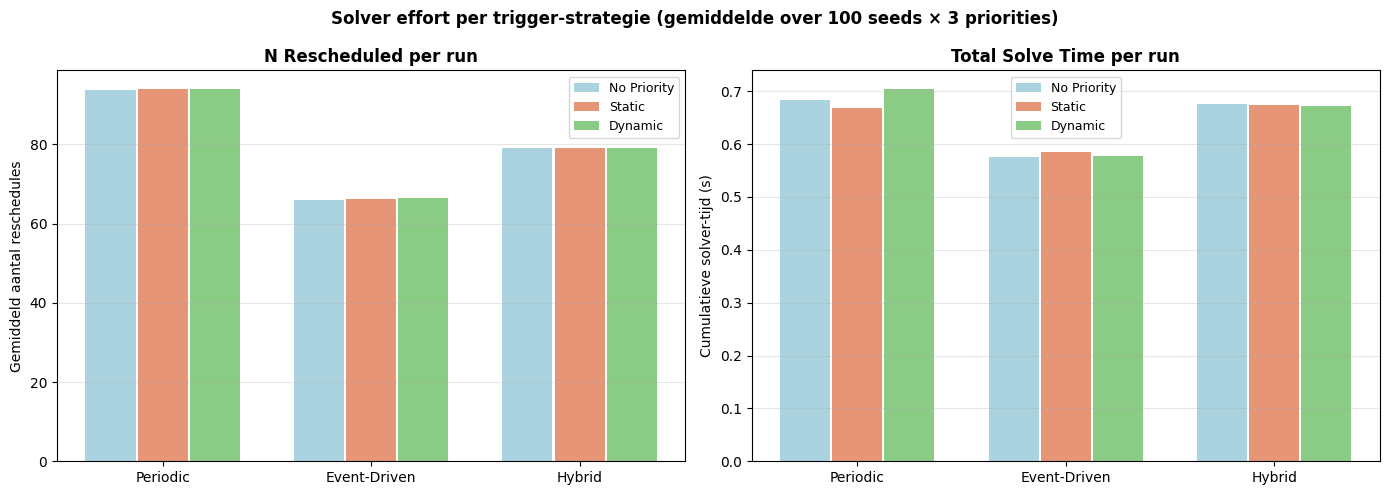

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Solver effort per trigger-strategie (gemiddelde over 100 seeds × 3 priorities)",
             fontsize=12, fontweight="bold")

# ── n_rescheduled ──────────────────────────────────────────────────────────
ax = axes[0]
for priority in PRIORITY_ORDER:
    vals = [
        raw[(raw["trigger"] == t) & (raw["priority"] == priority)]["n_rescheduled"].mean()
        for t in TRIGGER_ORDER
    ]
    x = np.arange(len(TRIGGER_ORDER))
    offset = PRIORITY_ORDER.index(priority) * 0.25 - 0.25
    ax.bar(x + offset, vals, width=0.24,
           label=PRIORITY_LABELS[priority], alpha=0.8,
           color=["#95C8D8", "#E07B54", "#6DBF67"][PRIORITY_ORDER.index(priority)])

ax.set_xticks(np.arange(len(TRIGGER_ORDER)))
ax.set_xticklabels([TRIGGER_LABELS[t] for t in TRIGGER_ORDER])
ax.set_ylabel("Gemiddeld aantal reschedules")
ax.set_title("N Rescheduled per run", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── total_solve_time ───────────────────────────────────────────────────────
ax2 = axes[1]
for priority in PRIORITY_ORDER:
    vals = [
        raw[(raw["trigger"] == t) & (raw["priority"] == priority)]["total_solve_time"].mean()
        for t in TRIGGER_ORDER
    ]
    offset = PRIORITY_ORDER.index(priority) * 0.25 - 0.25
    ax2.bar(x + offset, vals, width=0.24,
            label=PRIORITY_LABELS[priority], alpha=0.8,
            color=["#95C8D8", "#E07B54", "#6DBF67"][PRIORITY_ORDER.index(priority)])

ax2.set_xticks(np.arange(len(TRIGGER_ORDER)))
ax2.set_xticklabels([TRIGGER_LABELS[t] for t in TRIGGER_ORDER])
ax2.set_ylabel("Cumulatieve solver-tijd (s)")
ax2.set_title("Total Solve Time per run", fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "solver_effort_fase1.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.10  Infeasibility check

In [19]:
inf_tbl = raw.groupby(["trigger", "priority"]).agg(
    n_runs          = ("seed",           "count"),
    n_infeasible    = ("infeasible_run", "sum"),
    pct_infeasible  = ("infeasible_run", lambda x: 100 * x.sum() / len(x)),
    n_fcfs_fallback = ("n_fcfs_fallback","mean"),
).round(2)

print("Infeasibility overzicht (FCFS fallback = MIP faalde):")
display(inf_tbl)

total_inf = raw["infeasible_run"].sum()
if total_inf == 0:
    print("\n✓ Geen enkele run had een infeasible MIP-oplossing.")
else:
    print(f"\n⚠ {total_inf} runs hadden minstens één FCFS fallback.")


Infeasibility overzicht (FCFS fallback = MIP faalde):


n_runs  n_infeasible  pct_infeasible  \
trigger      priority                                            
periodic     no_priority     100             0             0.0   
             static          100             0             0.0   
             dynamic         100             0             0.0   
event_driven no_priority     100             0             0.0   
             static          100             0             0.0   
             dynamic         100             0             0.0   
hybrid       no_priority     100             0             0.0   
             static          100             0             0.0   
             dynamic         100             0             0.0   

                          n_fcfs_fallback  
trigger      priority                      
periodic     no_priority              0.0  
             static                   0.0  
             dynamic                  0.0  
event_driven no_priority              0.0  
             static                   0.0  
             dynamic                  0.0  
hybrid       no_priority              0.0  
             static                   0.0  
             dynamic                  0.0


✓ Geen enkele run had een infeasible MIP-oplossing.


### 4.11  Beste configuratie

Ranking op basis van (1) TED_combined, (2) delay_ratio dicht bij 1 (als prioriteit actief is).

In [20]:
ranking = raw.groupby(["trigger", "priority"]).agg(
    TED_combined_mean   = ("TED_combined",    "mean"),
    TED_passenger_mean  = ("TED_passenger",   "mean"),
    TED_freight_mean    = ("TED_freight",     "mean"),
    delay_ratio_mean    = ("delay_ratio",     lambda x: x.dropna().mean()),
    solve_time_mean     = ("total_solve_time","mean"),
    n_rescheduled_mean  = ("n_rescheduled",   "mean"),
).round(1).reset_index()

# Normaliseer TED_combined voor ranking (lager = beter)
ted_min = ranking["TED_combined_mean"].min()
ted_max = ranking["TED_combined_mean"].max()
ranking["TED_norm"] = (ranking["TED_combined_mean"] - ted_min) / (ted_max - ted_min + 1e-9)

# Ranking: laagste TED_norm
ranking = ranking.sort_values("TED_combined_mean")
ranking.index = range(1, len(ranking) + 1)
ranking.index.name = "Rank"

print("Ranking op TED_combined (lager = beter):")
display(ranking[["trigger","priority","TED_combined_mean","TED_passenger_mean",
                 "TED_freight_mean","delay_ratio_mean","solve_time_mean"]])


Ranking op TED_combined (lager = beter):


,trigger,priority,TED_combined_mean,TED_passenger_mean,TED_freight_mean,delay_ratio_mean,solve_time_mean
Rank,,,,,,,
1,periodic,no_priority,74709.7,61982.6,12727.1,1.2,0.7
2,hybrid,no_priority,75076.1,62126.8,12949.3,1.2,0.7
3,event_driven,no_priority,75106.7,62668.9,12437.8,1.1,0.6
4,event_driven,static,75108.3,62458.3,12650.0,1.1,0.6
5,periodic,dynamic,75112.8,62072.9,13039.9,1.2,0.7
6,event_driven,dynamic,75165.9,62500.8,12665.1,1.1,0.6
7,periodic,static,75179.3,62032.3,13146.9,1.2,0.7
8,hybrid,static,75468.7,62310.9,13157.8,1.2,0.7
9,hybrid,dynamic,75483.5,62374.2,13109.3,1.2,0.7


### 4.12  Aggregated CSV opslaan

Aggregeert elke config-dir naar `aggregated.csv` en laadt een gecombineerde tabel.

In [21]:
# Aggregeer elke config-directory
agg_frames = []
for cfg_dir in sorted(RESULTS_DIR.iterdir()):
    csv_path = cfg_dir / "raw_runs.csv"
    if csv_path.exists():
        try:
            agg = aggregate_config(cfg_dir)
            agg["config"] = cfg_dir.name
            agg_frames.append(agg)
            print(f"  Geaggregeerd: {cfg_dir.name}")
        except Exception as e:
            print(f"  FOUT bij {cfg_dir.name}: {e}")

if agg_frames:
    agg_all = pd.concat(agg_frames, ignore_index=True)
    agg_all.to_csv(RESULTS_DIR / "all_aggregated.csv", index=False)
    print(f"\nOpgeslagen: all_aggregated.csv  ({len(agg_all)} configuraties)")
    display(agg_all[["config","TED_combined_mean","TED_combined_std",
                      "delay_ratio_mean","delay_ratio_std",
                      "total_solve_time_mean","n_rescheduled_mean"]].round(2))


  Geaggregeerd: event_driven_dynamic
  Geaggregeerd: event_driven_no_priority
  Geaggregeerd: event_driven_static
  Geaggregeerd: hybrid_dynamic
  Geaggregeerd: hybrid_no_priority
  Geaggregeerd: hybrid_static
  Geaggregeerd: periodic_dynamic
  Geaggregeerd: periodic_no_priority
  Geaggregeerd: periodic_static

Opgeslagen: all_aggregated.csv  (9 configuraties)


,config,TED_combined_mean,TED_combined_std,delay_ratio_mean,delay_ratio_std,total_solve_time_mean,n_rescheduled_mean
0,event_driven_dynamic,75165.87,3878.20,1.15,0.17,0.58,66.59
1,event_driven_no_priority,75106.71,3862.31,1.12,0.16,0.56,66.54
2,event_driven_static,75108.33,3908.06,1.15,0.17,0.58,66.31
3,hybrid_dynamic,75483.51,3201.05,1.19,0.18,0.67,79.44
4,hybrid_no_priority,75076.13,3406.93,1.18,0.17,0.66,79.42
5,hybrid_static,75468.67,3221.24,1.19,0.18,0.67,79.40
6,periodic_dynamic,75112.77,3633.60,1.19,0.19,0.70,93.98
7,periodic_no_priority,74709.69,3574.63,1.16,0.16,0.68,93.97
8,periodic_static,75179.27,3471.19,1.20,0.18,0.67,93.98
